# Knowledge Base

## Section A: Semantic Network

* Define Semantic Network below:
  * John is father of Paul
  * Mary is mother of Paul
  * John is father of Anna
  * Mary is mother of Anna
  * Paul is sibling of Anna

Method 1:

In [10]:
class Person:
    pass

class John(Person):
    pass

class Mary(Person):
    pass

class Paul(Person):
    pass

class Anna(Person):
    pass

semantic_network = {
    "John": {"father_of": ["Paul", "Anna"]},
    "Mary": {"mother_of": ["Paul", "Anna"]},
    "Paul": {"sibling_of": ["Anna"]},
    "Anna": {"sibling_of": ["Paul"]}
}

for person, relations in semantic_network.items():
    for relation, targets in relations.items():
        print(f"{person} is {relation} {', '.join(targets)}")


John is father_of Paul, Anna
Mary is mother_of Paul, Anna
Paul is sibling_of Anna
Anna is sibling_of Paul


Method 2:

Semantic Network Relations:
John --father_of--> Paul
John --father_of--> Anna
Paul --sibling_of--> Anna
Mary --mother_of--> Paul
Mary --mother_of--> Anna
Anna --sibling_of--> Paul


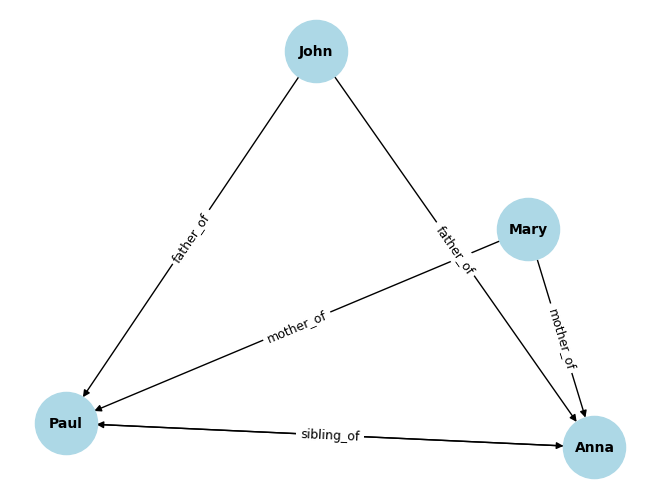

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

# Add relations as edges with labels
G.add_edge("John", "Paul", relation="father_of")
G.add_edge("Mary", "Paul", relation="mother_of")
G.add_edge("John", "Anna", relation="father_of")
G.add_edge("Mary", "Anna", relation="mother_of")
G.add_edge("Paul", "Anna", relation="sibling_of")
G.add_edge("Anna", "Paul", relation="sibling_of")

# Print relations
print("Semantic Network Relations:")
for u, v, data in G.edges(data=True):
    print(f"{u} --{data['relation']}--> {v}")

# Draw graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", 
        node_size=2000, font_size=10, font_weight="bold")
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.show()

## Section B: Frame

* Create frame below:
  * Computer is a class <br>
  * Desktop is a Computer <br>
  * Laptop is a Computer <br>
  * Laptop model is HP

In [12]:
class Computer:
    model=''
    color='black'

    def __init__(self,model,color='black'):
        self.model=model
        self.color=color

    def switchOn():
        print("On")

    def switchOff():
        print("Off")

class Desktop(Computer):
    pass

class Laptop(Computer):
    
    def __init__(self,model,color='black'):
       super().__init__(model,color)
 
hp=Laptop('HP','silver')
dell=Desktop('Dell')
print("This is a " + hp.model + " laptop")
print("This is a " + dell.color + " desktop")


This is a HP laptop
This is a black desktop


## Section C: Ontology

In [13]:
pip install rdflib

Note: you may need to restart the kernel to use updated packages.


In [14]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal, BNode
from rdflib.namespace import OWL, XSD 

# Create an RDF graph
g = Graph()

# Define a namespace
EX = Namespace("nm")

# Add Classes
g.add((EX.Animal, RDF.type, RDFS.Class))
g.add((EX.Mammal, RDF.type, RDFS.Class))
g.add((EX.Cat, RDF.type, RDFS.Class))

# Add Parent-Child Classes
g.add((EX.Mammal, RDFS.subClassOf, EX.Animal))
g.add((EX.Cat, RDFS.subClassOf, EX.Mammal))

# Add Properties to Class
g.add((EX.hasTail, RDF.type, RDF.Property))
g.add((EX.hasTail, RDFS.domain, EX.Mammal))
g.add((EX.hasTail, RDFS.range, RDFS.Literal))

# Add Instances
g.add((EX.Garfield, RDF.type, EX.Cat))
g.add((EX.Garfield, EX.hasTail, Literal(True, datatype=XSD.boolean)))

# Add Relations
g.add((EX.Garfield, OWL.differentFrom, EX.ThunderCat))

# Add Constraints
restriction = BNode()
g.add((restriction, RDF.type, OWL.Restriction))
g.add((restriction, OWL.onProperty, EX.hasTail))
g.add((restriction, OWL.hasValue, Literal(True, datatype=XSD.boolean)))
g.add((EX.Cat, RDFS.subClassOf, restriction))

# Print RDF graph in Turtle format
print(g.serialize(format="turtle"))

@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<nmAnimal> a rdfs:Class .

<nmCat> a rdfs:Class ;
    rdfs:subClassOf [ a owl:Restriction ;
            owl:hasValue true ;
            owl:onProperty <nmhasTail> ],
        <nmMammal> .

<nmMammal> a rdfs:Class ;
    rdfs:subClassOf <nmAnimal> .

<nmGarfield> a <nmCat> ;
    owl:differentFrom <nmThunderCat> ;
    <nmhasTail> true .

<nmhasTail> a rdf:Property ;
    rdfs:domain <nmMammal> ;
    rdfs:range rdfs:Literal .




Visualize in graph

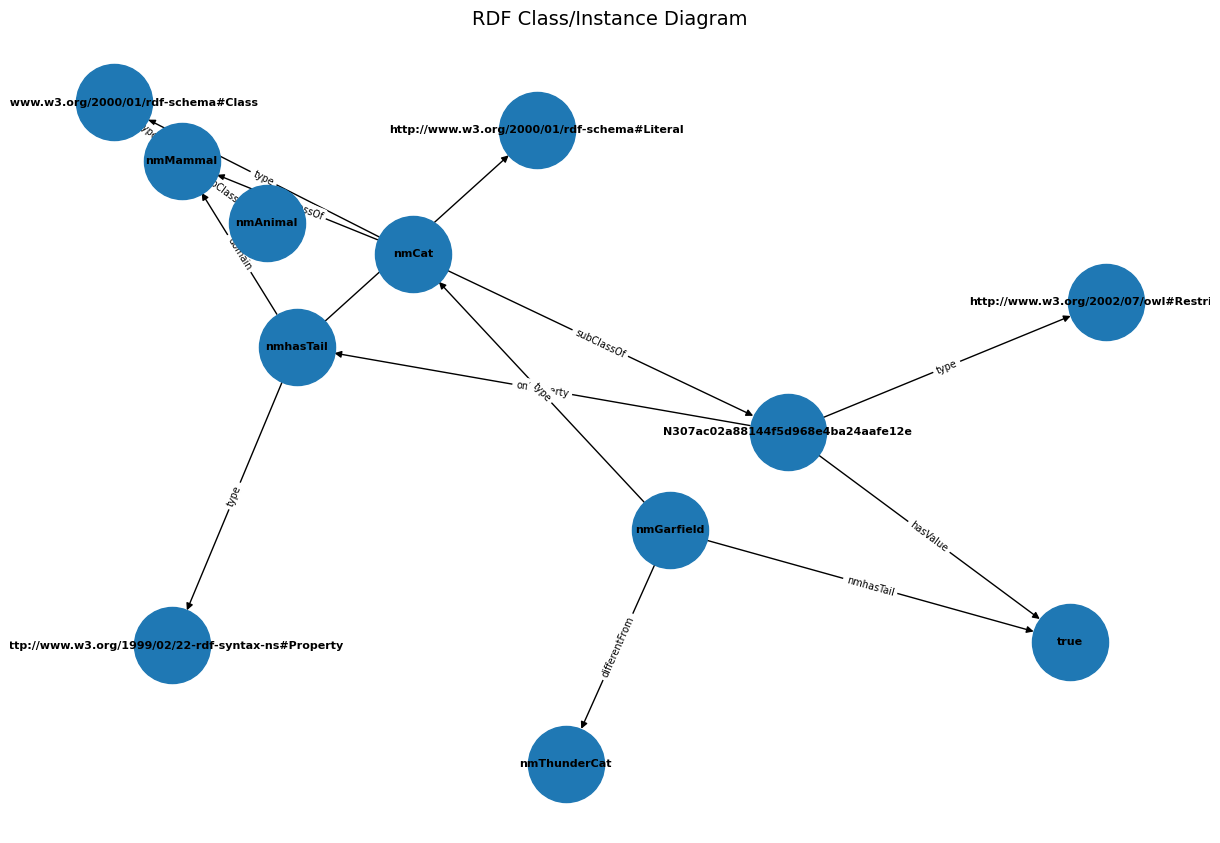

In [15]:
import networkx as nx
import matplotlib.pyplot as plt
# -------------------------
# Convert RDFLib -> NetworkX
# -------------------------
nx_graph = nx.DiGraph()

for s, p, o in g:
    nx_graph.add_edge(str(s), str(o), label=str(p).split('#')[-1])

pos = nx.spring_layout(nx_graph, seed=42)

plt.figure(figsize=(12, 8))
nx.draw(nx_graph, pos, with_labels=True, node_size=3000, 
        font_size=8, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(
    nx_graph, pos,
    edge_labels={(u, v): d['label'] for u, v, d in nx_graph.edges(data=True)},
    font_size=7
)

plt.title("RDF Class/Instance Diagram", fontsize=14)
plt.show()

## Section D: Production Rules in CLIPS 

Define IF...Then....

In [16]:
pip install clipspy

Note: you may need to restart the kernel to use updated packages.


In [17]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=15,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(defrule room
                (cold)
             =>
             (printout t "Best plant is ivy!" crlf))""")

# Display rules
# env.eval("(list-defrules)")  
env.eval("(ppdefrule room)")


(defrule MAIN::room
   (cold)
   =>
   (printout t "Best plant is ivy!" crlf))


## Section E: Case Base in Case Based Reasoning (CBR) - Adaptive Behavior

Define problems and solutions

In [18]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=15,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Representing a case
env.build("""(deftemplate car-troubleshooting
                   (slot can-start)
                   (slot engine-noise)
                   (slot solution))""")

fact=""
with open('case_base.txt', 'r') as file:
    for line in file:
        fact=fact+line.strip()
    env.build("""(deffacts case """+fact+""")""")

env.eval("(ppdeffacts case)")

(deffacts MAIN::case
   (car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt))
   (car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery))
   (car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel)))


## Section F: Manual Decision Trees / Automatic Rules Generation (Adaptive Behavior) 

* In traditional method, knowledge engineer manually updates into the KB. A simple example of **modern approach** how expert systems hybrid with **machine learning** techniques for **adaptability**.

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



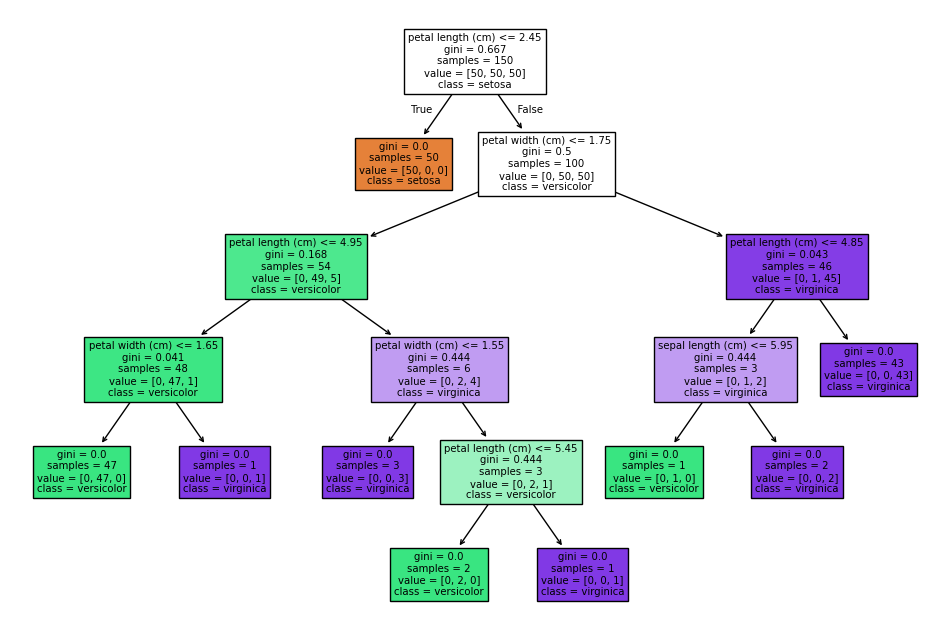

In [19]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train the dataset
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X, y)

# Convert the rules to text
rules = export_text(clf, feature_names=data.feature_names)
print(rules)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names, filled=True)
# If doesn't work, please use below.
#plot_tree(clf)
plt.show()

## Section G: Fuzzy

Define rules

In [20]:
rules = [
    ("Temp", "Cold", "Fan", "Low"),
    ("Temp", "Warm", "Fan", "Medium"),
    ("Temp", "Hot", "Fan", "High")
]

Define fuzzy sets using functions

In [21]:
def fuzzy_temperature(temp):
    """Return fuzzy membership values for temperature."""
    return {
        "Cold": max(0, min(1, (20 - temp) / 10)),   # 1 at <=10, 0 at >=20
        "Warm": max(0, 1 - abs(temp - 25) / 10),    # peak at 25
        "Hot": max(0, min(1, (temp - 20) / 10))     # 0 at <=20, 1 at >=30
    }

def fuzzy_fan(speed_level):
    """Return fuzzy membership values for fan speed."""
    return {
        "Low": max(0, min(1, (50 - speed_level) / 25)),    # 1 at <=25, 0 at >=50
        "Medium": max(0, 1 - abs(speed_level - 50) / 25),  # peak at 50
        "High": max(0, min(1, (speed_level - 50) / 25))    # 0 at <=50, 1 at >=75
    }

Display fuzzy knowledge

In [ ]:
print("=== Fuzzy Rules ===")
for rule in rules:
    print(f"IF {rule[0]} IS {rule[1]} THEN {rule[2]} IS {rule[3]}")
    
print("\n=== Fuzzy Temperature Sets ===")
temp_samples = [0, 10, 15, 20, 25, 30, 35]
for t in temp_samples:
    memberships = fuzzy_temperature(t)
    print(f"Temp = {t}: {memberships}")
    
print("\n=== Fuzzy Fan Speed Sets ===")
fan_samples = [0, 25, 40, 50, 60, 75, 100]
for s in fan_samples:
    memberships = fuzzy_fan(s)
    print(f"Fan Speed = {s}: {memberships}")

=== Fuzzy Rules ===
IF Temp IS Cold THEN Fan IS Low
IF Temp IS Warm THEN Fan IS Medium
IF Temp IS Hot THEN Fan IS High

=== Fuzzy Temperature Sets ===
Temp = 0: {'Cold': 1, 'Warm': 0, 'Hot': 0}
Temp = 10: {'Cold': 1, 'Warm': 0, 'Hot': 0}
Temp = 15: {'Cold': 0.5, 'Warm': 0, 'Hot': 0}
Temp = 20: {'Cold': 0, 'Warm': 0.5, 'Hot': 0}
Temp = 25: {'Cold': 0, 'Warm': 1.0, 'Hot': 0.5}
Temp = 30: {'Cold': 0, 'Warm': 0.5, 'Hot': 1}
Temp = 35: {'Cold': 0, 'Warm': 0, 'Hot': 1}

=== Fuzzy Fan Speed Sets ===
Fan Speed = 0: {'Low': 1, 'Medium': 0, 'High': 0}
Fan Speed = 25: {'Low': 1, 'Medium': 0, 'High': 0}
Fan Speed = 40: {'Low': 0.4, 'Medium': 0.6, 'High': 0}
Fan Speed = 50: {'Low': 0, 'Medium': 1.0, 'High': 0}
Fan Speed = 60: {'Low': 0, 'Medium': 0.6, 'High': 0.4}
Fan Speed = 75: {'Low': 0, 'Medium': 0, 'High': 1}
Fan Speed = 100: {'Low': 0, 'Medium': 0, 'High': 1}
